In [2]:
from typing import Optional
from collections import defaultdict

from pathlib import Path

from tqdm import tqdm

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import torch

from torchmetrics.classification import BinaryAUROC, BinaryF1Score, BinaryAccuracy
from torchmetrics.regression import MeanSquaredError, MeanAbsoluteError, R2Score

from relbench.tasks import get_task

from notebooks.utils import get_potato_client, get_experiment_runs_df

from experiments.continuous_learning.continuous_task import ContinuousWrapper

%reload_ext autoreload
%autoreload 2

In [ ]:
experiments = [
    "pelesjak_cl_from_scratch",
    "pelesjak_cl_ft_full",
    "pelesjak_cl_ft_upsample",
    "pelesjak_cl_ft_newonly",
]
client = get_potato_client()
for experiment in experiments:
    df = get_experiment_runs_df(client, experiment, "status = 'FINISHED'")
    df.to_csv(f"./data/{experiment}.csv", index=False)

In [17]:
dataset_task_pairs = [
    ('rel-avito','ad-ctr'),
    ('rel-avito','user-clicks'),
    ('rel-avito','user-visits'),
    ('rel-f1','driver-position'),
    ('rel-f1','driver-dnf'),
    ('rel-f1','driver-top3'),
    ('rel-stack','post-votes'),
    ('rel-stack','user-badge'),
    ('rel-stack','user-engagement'),
    ('rel-trial','site-success'),
    ('rel-trial','study-adverse'),
    ('rel-trial','study-outcome'),
]
tasks: dict[tuple[str, str], ContinuousWrapper] = {}

for dataset_name, task_name in dataset_task_pairs:
    task = get_task(dataset_name, task_name, download=False)
    tasks[(dataset_name, task_name)] = ContinuousWrapper(task)
    

cherry_picked_pairs = [
    ('rel-avito','ad-ctr'),
    ('rel-f1','driver-position'),
    ('rel-stack', 'user-engagement'),
    ('rel-trial','study-adverse')
]

## Task Infographics


100%|██████████| 4/4 [00:00<00:00, 17.50it/s]


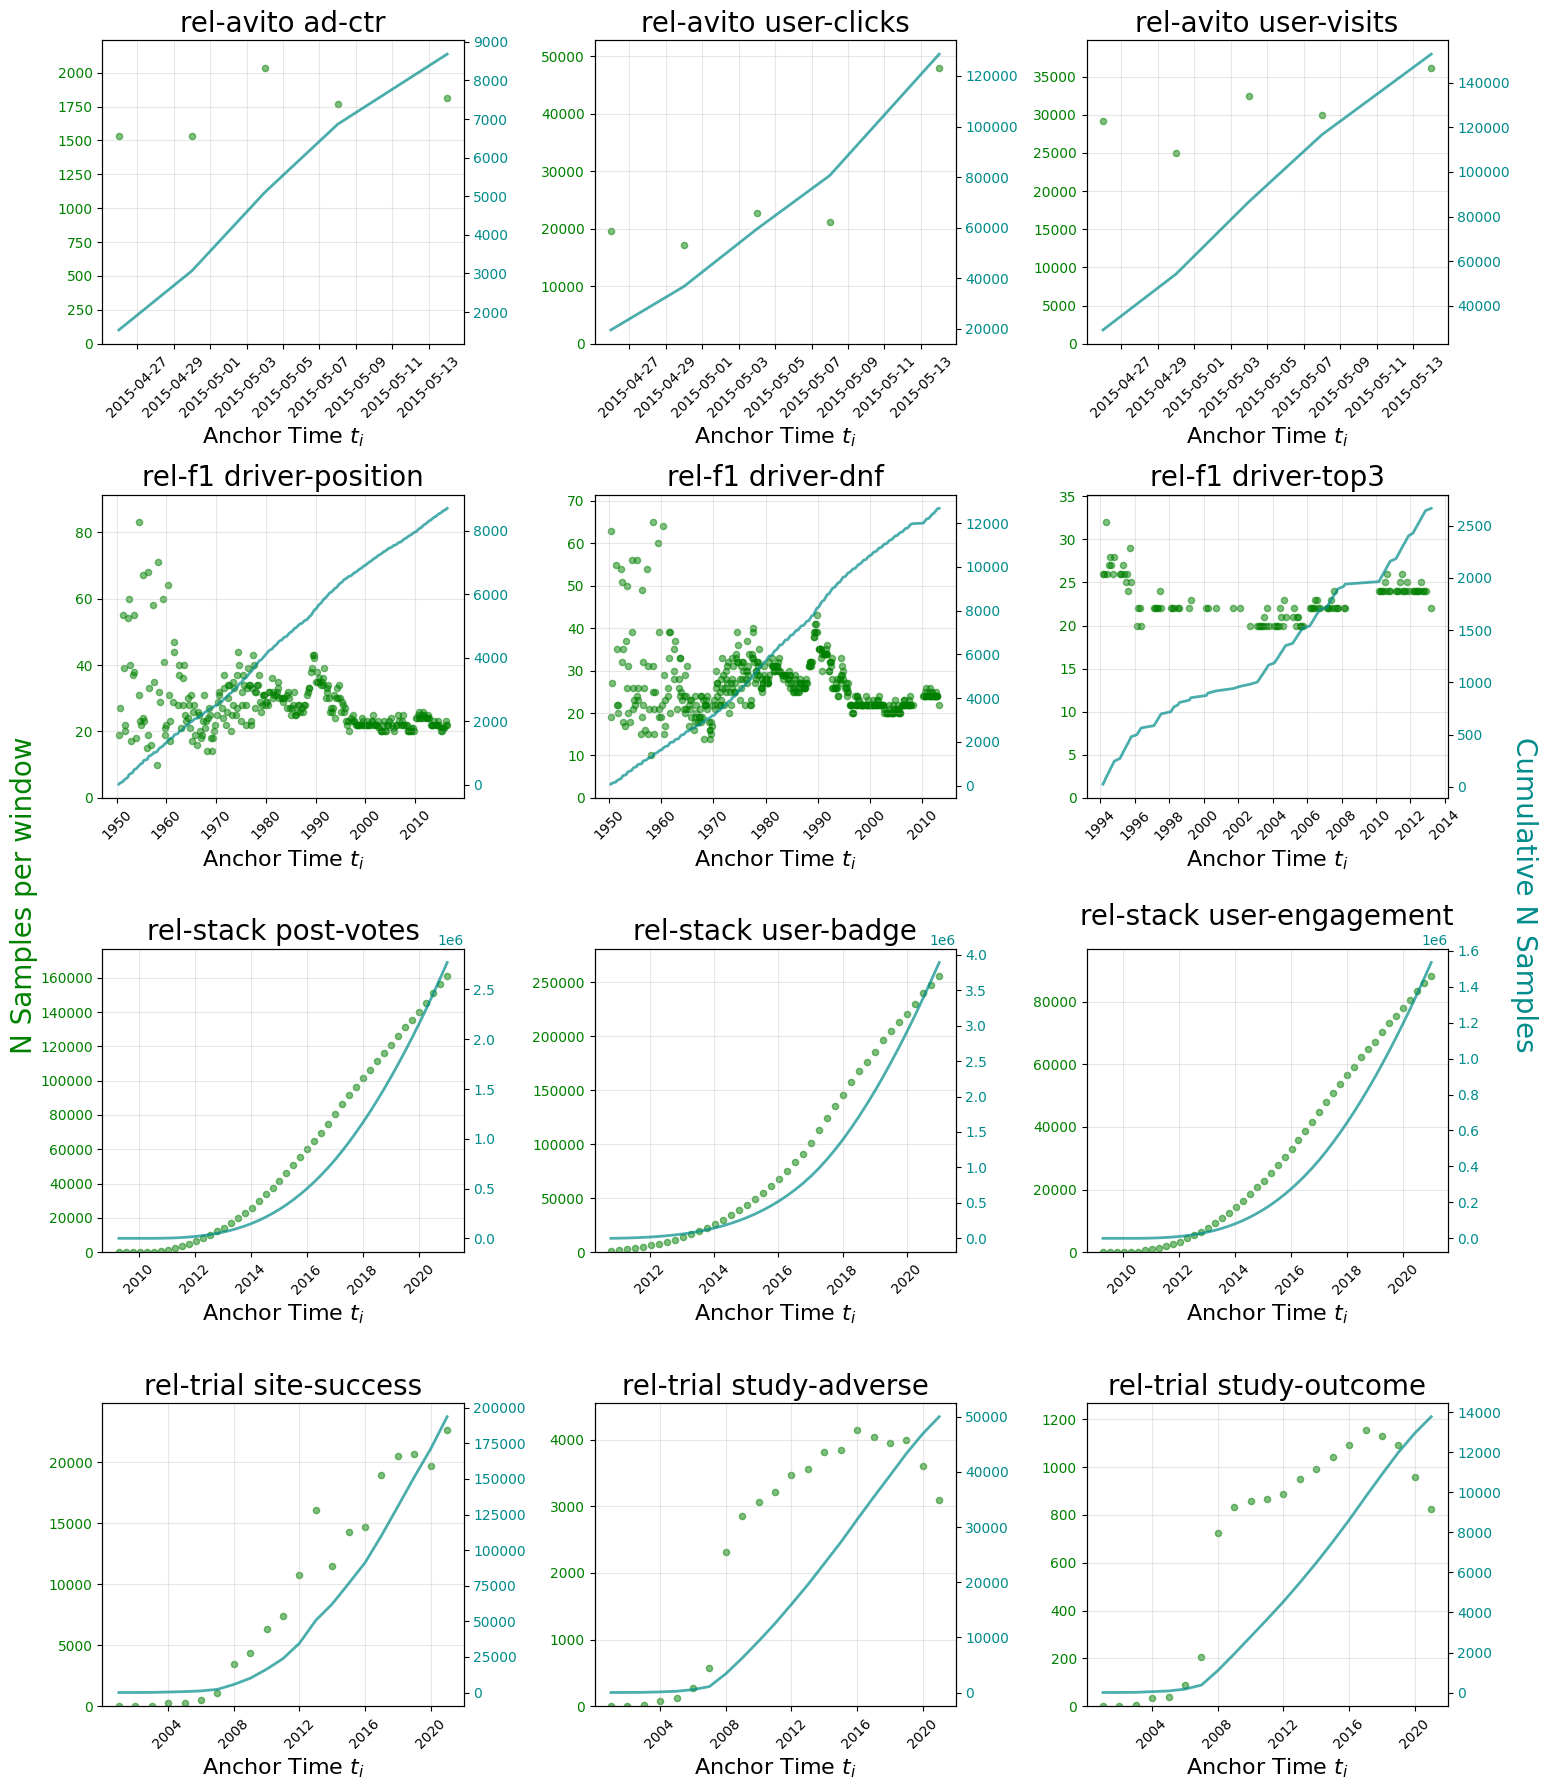

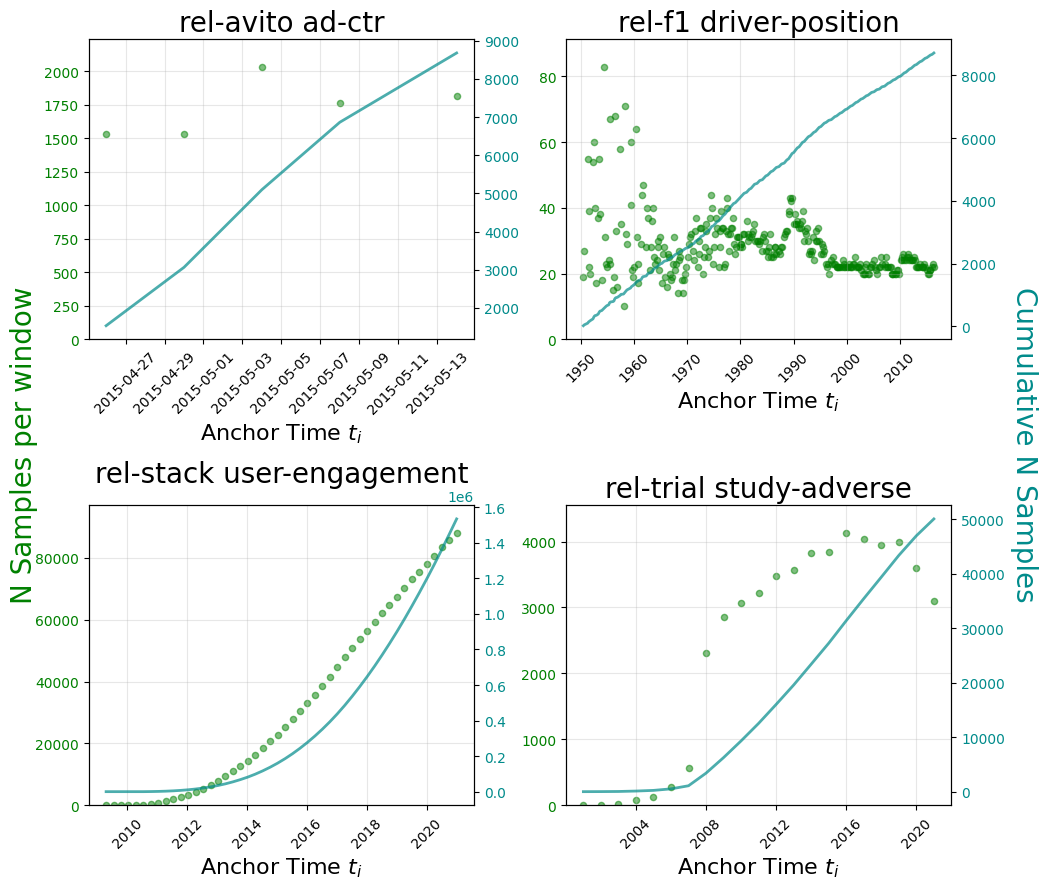

In [18]:
def plot_window_sizes(df: pd.DataFrame, splits: list,time_col: str, ax1: plt.Axes, ax2: plt.Axes):  
    color1 = 'green'
    
    counts = [len(df[df[time_col] == split] ) for split in splits]
    cumulative_counts = np.cumsum(counts)
    
    color2 = 'darkcyan'
    ax2.plot(splits, cumulative_counts, linewidth=2, color=color2, alpha=0.7, label='Cumulative N Samples')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    color1 = 'green'
    ax1.set_xlabel("Anchor Time $t_i$", fontsize=16)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.scatter(splits, counts, marker='o', s=20, alpha=0.5, color=color1, label='N Samples per window')
    ax1.set_ylim(0, max(counts) * 1.1)
    ax1.grid(True, alpha=0.3, which='both')
    for tick in ax1.get_xticklabels():
        tick.set_rotation(45)

def make_window_sizes_plots(dataset_pairs: list[tuple[str, str]], nrows: int = 4, ncols: int = 3, save_path: Optional[Path] = None):
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5*ncols, 4.5*nrows), tight_layout=True)
    fig.text(-0.01, 0.5, 'N Samples per window', 
            va='center', rotation='vertical', color='green', fontsize=20)

    # Right side label
    fig.text(0.99, 0.5, 'Cumulative N Samples', 
            va='center', rotation=270, color='darkcyan',  fontsize=20)

    for i, (dataset_name, task_name) in tqdm(enumerate(dataset_pairs), total=len(dataset_pairs)):
        ax1 = axes[i // ncols, i % ncols] if nrows > 1 else axes[i % ncols]
        ax2 = ax1.twinx()
        
        table = tasks[(dataset_name, task_name)].full_table
        df = table.df
        
        splits = df[table.time_col].unique()
        splits = np.sort(splits)
        plot_window_sizes(df, splits, table.time_col, ax1, ax2)
        ax1.set_title(f"{dataset_name} {task_name}", fontsize=20)
        
    # lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
    # lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

    # unique_labels = labels[:2]
    # unique_lines = lines[:2]

    # fig.legend(
    #     unique_lines,
    #     unique_labels,
    #     loc="lower center",
    #     ncol=2,
    #     prop={"size": 16},
    #     bbox_to_anchor=(0.5, 0.99),
    # )
    # fig.suptitle("")
    # fig.align_xlabels()
    # fig.align_ylabels()
    # fig.tight_layout(h_pad=0)
    # fig.show()
        
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        
make_window_sizes_plots(dataset_task_pairs, nrows=4, ncols=3, save_path=Path("./data/figures/task_window_sizes_full.png"))
make_window_sizes_plots(cherry_picked_pairs, nrows=2, ncols=2, save_path=Path("./data/figures/task_window_sizes_cherry_picked.png"))

100%|██████████| 12/12 [00:02<00:00,  5.50it/s]
/tmp/ipykernel_120795/2809530275.py:93: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 4/4 [00:00<00:00,  9.71it/s]


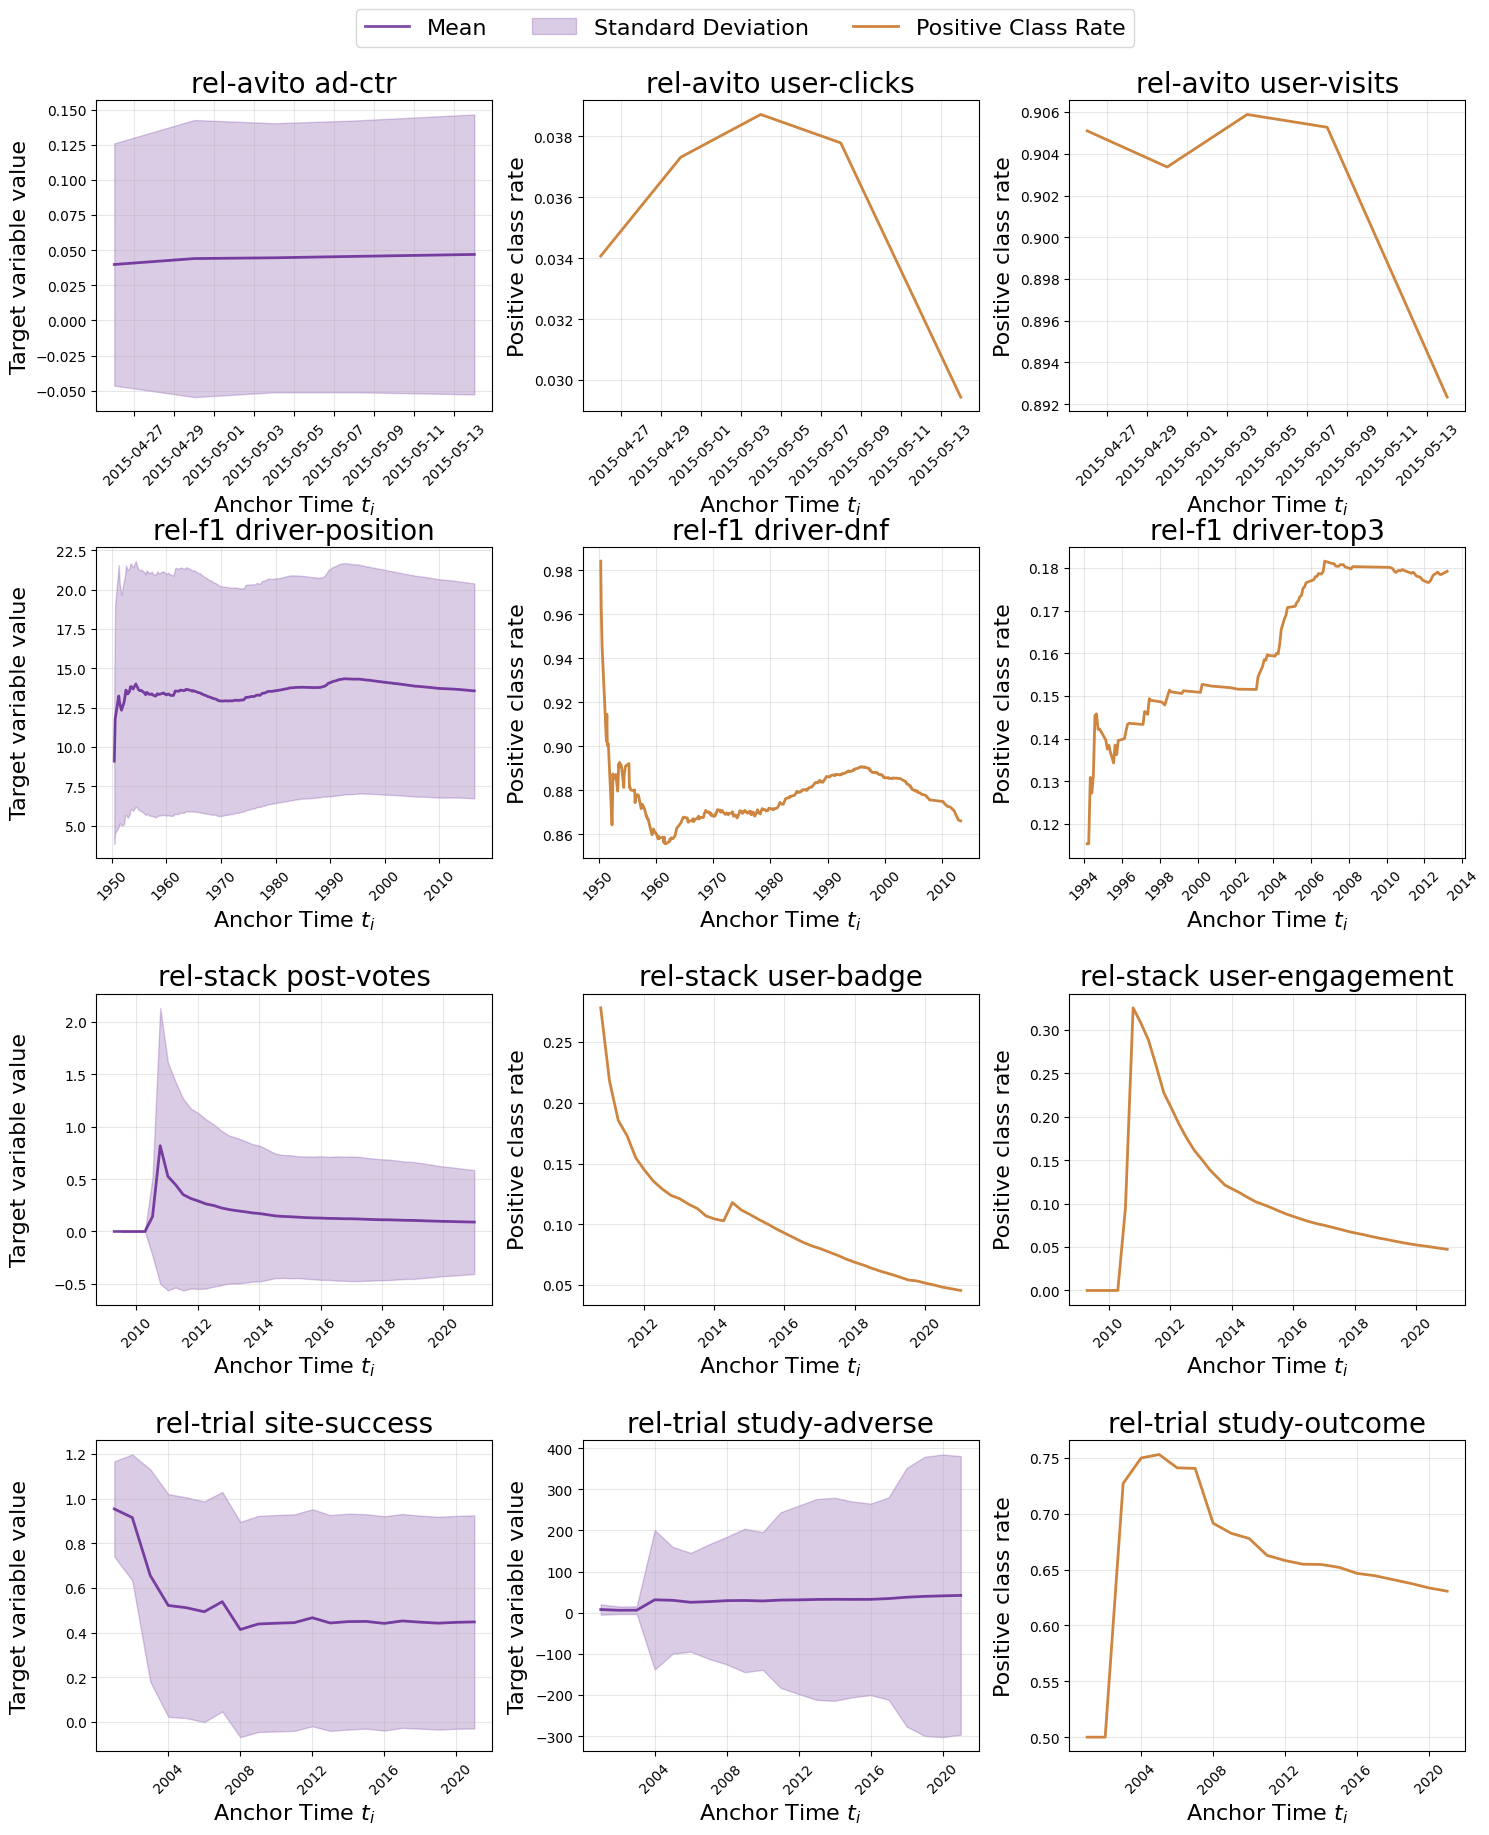

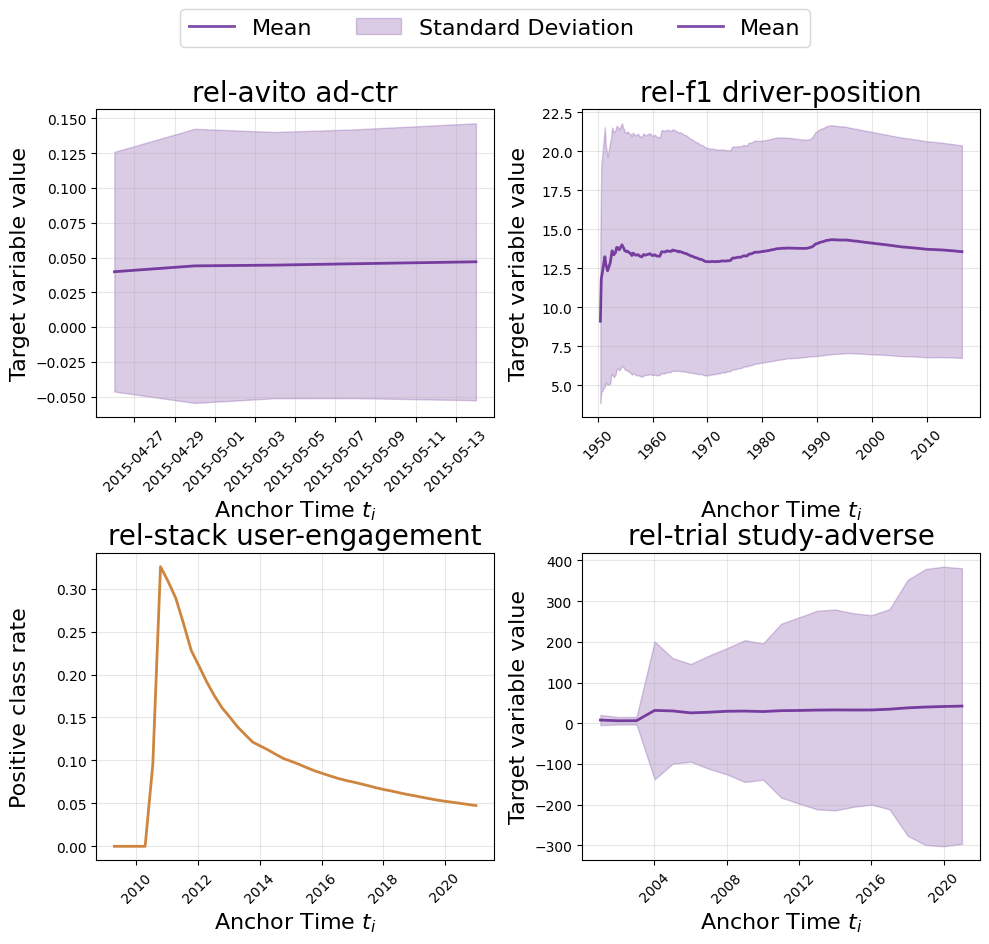

In [19]:
def plot_regression_task(
    df: pd.DataFrame, splits: list, time_col: str, target_col: str, ax: plt.Axes
):
    color = "indigo"
    cumulative_mean = []
    cumulative_std = []
    for split in splits:
        split_df = df[df[time_col] <= split]
        cumulative_mean.append(split_df[target_col].mean())
        cumulative_std.append(split_df[target_col].std())

    ax.plot(splits, cumulative_mean, linewidth=2, color=color, alpha=0.7, label="Mean")
    ax.fill_between(
        splits,
        np.array(cumulative_mean) - np.array(cumulative_std),
        np.array(cumulative_mean) + np.array(cumulative_std),
        color=color,
        alpha=0.2,
        label="Standard Deviation",
    )
    ax.set_ylabel("Target variable value", fontsize=16)


def plot_binary_classification_task(
    df: pd.DataFrame, splits: list, time_col: str, target_col: str, ax: plt.Axes
):
    color = "peru"
    cumulative_pos_rate = []
    for split in splits:
        split_df = df[df[time_col] <= split]
        cumulative_pos_rate.append(split_df[target_col].mean())
    ax.plot(
        splits,
        cumulative_pos_rate,
        linewidth=2,
        color=color,
        label=f"Positive Class Rate",
    )
    ax.set_ylabel("Positive class rate", fontsize=16)


def make_target_value_plots(
    dataset_pairs: list[tuple[str, str]], nrows: int = 4, ncols: int = 3, save_path: Optional[Path] = None
):
    fig, axes = plt.subplots(
        ncols=ncols, nrows=nrows, figsize=(5 * ncols, 4.5 * nrows), tight_layout=True
    )

    for i, (dataset_name, task_name) in tqdm(
        enumerate(dataset_pairs), total=len(dataset_pairs)
    ):
        ax = axes[i // ncols, i % ncols] if nrows > 1 else axes[i % ncols]

        task = tasks[(dataset_name, task_name)]

        table = tasks[(dataset_name, task_name)].full_table
        df = table.df
        splits = df[table.time_col].unique()
        splits = np.sort(splits)

        if task.task.task_type.value == "regression":
            plot_regression_task(df, splits, table.time_col, task.task.target_col, ax)

        elif task.task.task_type.value == "binary_classification":
            plot_binary_classification_task(
                df, splits, table.time_col, task.task.target_col, ax
            )
            
        ax.set_title(f"{dataset_name} {task_name}", fontsize=20)
        ax.set_xlabel("Anchor Time $t_i$", fontsize=16)
        ax.grid(True, alpha=0.3, which="both")
        for tick in ax.get_xticklabels():
            tick.set_rotation(45)

    lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
    lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

    unique_labels = labels[:3]
    unique_lines = lines[:3]

    fig.legend(
        unique_lines,
        unique_labels,
        loc="lower center",
        ncol=3,
        prop={"size": 16},
        bbox_to_anchor=(0.5, 0.99),
    )
    fig.suptitle("")
    fig.align_xlabels()
    fig.align_ylabels()
    fig.tight_layout(h_pad=0)
    fig.show()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        
        
make_target_value_plots(dataset_task_pairs, nrows=4, ncols=3, save_path=Path("./data/figures/task_window_target_full.png"))
make_target_value_plots(cherry_picked_pairs, nrows=2, ncols=2, save_path=Path("./data/figures/task_window_target_cherry_picked.png"))

In [20]:
info_dict = defaultdict(list)

for dn, tn in dataset_task_pairs:
    task_wrapper = tasks[(dn, tn)]
    task = task_wrapper.task
    df = task_wrapper.full_table.df
    table = task_wrapper.full_table

    info_dict["dataset"].append(dn)
    info_dict["task"].append(tn)
    info_dict["train"].append(len(task_wrapper.train_table.df))
    info_dict["val"].append(len(task_wrapper.val_table.df))
    info_dict["test"].append(len(task_wrapper.test_table.df))
    
    windows = task_wrapper.full_table.df[task_wrapper.full_table.time_col].unique()
    windows = np.sort(windows)
    info_dict["num_windows"].append(len(windows))
    splits = task_wrapper.get_splits()
    info_dict["num_increments"].append(len(splits))
    
    
    info_dict["avg_window_samples"].append(
        np.mean(
            [
                len(
                    task_wrapper.get_table(
                        start=windows[i],
                        end=windows[i + 1] if i + 1 < len(windows) else None,
                    )
                )
                for i in range(len(windows) - 1)
            ]
        )
    )
    info_dict["avg_icr_samples"].append(
        np.mean(
            [
                len(
                    task_wrapper.get_table(
                        start=splits[i],
                        end=splits[i + 1] if i + 1 < len(splits) else None,
                    )
                )
                for i in range(len(splits) - 1)
            ]
        )
    )
    info_dict["window_size"].append(
        np.mean([windows[i + 1] - windows[i] for i in range(len(windows) - 1)]).astype('timedelta64[D]').astype(int)
    )
    info_dict["increment_size"].append(
        np.mean([splits[i + 1] - splits[i] for i in range(len(splits) - 1)]).days
    )
print(info_dict)
info_df = pd.DataFrame(info_dict)
info_df.set_index(["dataset", "task"], inplace=True)
display(info_df)

info_df.to_latex("./data/tables/task_window_info.tex", float_format="{:.0f}".format, escape=True)

defaultdict(<class 'list'>, {'dataset': ['rel-avito', 'rel-avito', 'rel-avito', 'rel-f1', 'rel-f1', 'rel-f1', 'rel-stack', 'rel-stack', 'rel-stack', 'rel-trial', 'rel-trial', 'rel-trial'], 'task': ['ad-ctr', 'user-clicks', 'user-visits', 'driver-position', 'driver-dnf', 'driver-top3', 'post-votes', 'user-badge', 'user-engagement', 'site-success', 'study-adverse', 'study-outcome'], 'train': [5100, 59454, 86619, 7453, 11411, 1353, 2453921, 3386276, 1360850, 151407, 43335, 11994], 'val': [1766, 21183, 29979, 499, 566, 588, 156216, 247398, 85838, 19740, 3596, 960], 'test': [1816, 47996, 36129, 760, 702, 726, 160903, 255360, 88137, 22617, 3098, 825], 'num_windows': [5, 5, 5, 310, 475, 116, 48, 42, 48, 21, 21, 21], 'num_increments': [4, 4, 4, 13, 13, 4, 20, 19, 20, 9, 9, 9], 'avg_window_samples': [1716.5, 20159.25, 29149.5, 28.12297734627832, 26.70253164556962, 23.0, 55534.82978723404, 88626.19512195123, 30780.59574468085, 8557.35, 2346.55, 647.7], 'avg_icr_samples': [2288.6666666666665, 268

train     val    test  num_windows  \
dataset   task                                                    
rel-avito ad-ctr              5100    1766    1816            5   
          user-clicks        59454   21183   47996            5   
          user-visits        86619   29979   36129            5   
rel-f1    driver-position     7453     499     760          310   
          driver-dnf         11411     566     702          475   
          driver-top3         1353     588     726          116   
rel-stack post-votes       2453921  156216  160903           48   
          user-badge       3386276  247398  255360           42   
          user-engagement  1360850   85838   88137           48   
rel-trial site-success      151407   19740   22617           21   
          study-adverse      43335    3596    3098           21   
          study-outcome      11994     960     825           21   

                           num_increments  avg_window_samples  \
dataset   task                                                  
rel-avito ad-ctr                        4         1716.500000   
          user-clicks                   4        20159.250000   
          user-visits                   4        29149.500000   
rel-f1    driver-position              13           28.122977   
          driver-dnf                   13           26.702532   
          driver-top3                   4           23.000000   
rel-stack post-votes                   20        55534.829787   
          user-badge                   19        88626.195122   
          user-engagement              20        30780.595745   
rel-trial site-success                  9         8557.350000   
          study-adverse                 9         2346.550000   
          study-outcome                 9          647.700000   

                           avg_icr_samples  window_size  increment_size  
dataset   task                                                           
rel-avito ad-ctr               2288.666667            4               6  
          user-clicks         26879.000000            4               6  
          user-visits         38866.000000            4               6  
rel-f1    driver-position       662.666667           77            1812  
          driver-dnf            998.083333           48            1814  
          driver-top3           647.000000           60            1928  
rel-stack post-votes         137375.631579           91             225  
          user-badge         201870.777778           91             207  
          user-engagement     76141.473684           91             225  
rel-trial site-success        21393.375000          365             912  
          study-adverse        5866.375000          365             912  
          study-outcome        1619.250000          365             912

## Results


In [21]:
def exp_decay_avg(metrics, counts = None, decay = 0):
    counts = np.ones_like(metrics) if counts is None else np.array(counts)
    weights = (np.power(1 - decay,np.arange(len(metrics))) * counts) / counts.sum()
    return np.average(metrics, weights=weights)

In [22]:
def calculate_metric_for_split(
    data,
    wrapped_task: ContinuousWrapper,
    split: float,
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    decay: float = 0.0,
    with_std: bool = False
) -> pd.DataFrame:
    task = wrapped_task.task
    table = wrapped_task.full_table
    split_data: pd.DataFrame = data[
        (data[table.time_col] >= start_time) & (data[table.time_col] < end_time)
    ]

    preds = split_data.drop(columns=[table.time_col, task.target_col, task.entity_col])
    cols = preds.columns[preds.columns.str.startswith(f"{split}_")]
    preds = preds[cols]

    windows = split_data[table.time_col].unique()
    windows = np.sort(windows)

    metrics = defaultdict(list)

    for col in preds.columns:
        col_metrics = defaultdict(list)
        col_counts = []
        for window in windows:
            window_data = split_data[split_data[table.time_col] == window]
            # window_data = split_data
            y_true = torch.tensor(
                window_data[task.target_col].values,
                dtype=(
                    torch.float if task.task_type.value == "regression" else torch.long
                ),
            )
            y_pred = torch.tensor(window_data[col].values, dtype=torch.float)
            
            col_counts.append(len(window_data))
            if task.task_type.value == "binary_classification":
                col_metrics["auroc"].append(
                    BinaryAUROC().to("cpu")(y_pred, y_true.int()).item()
                )
                col_metrics["f1"].append(
                    BinaryF1Score().to("cpu")(y_pred, y_true.int()).item()
                )
                col_metrics["accuracy"].append(
                    BinaryAccuracy().to("cpu")(y_pred, y_true.int()).item()
                )
            elif task.task_type.value == "regression":
                col_metrics["mse"].append(
                    MeanSquaredError().to("cpu")(y_pred, y_true).item()
                )
                col_metrics["mae"].append(
                    MeanAbsoluteError().to("cpu")(y_pred, y_true).item()
                )
                col_metrics["r2"].append(R2Score().to("cpu")(y_pred, y_true).item())
        for metric_name, metric_values in col_metrics.items():
            metrics[metric_name].append(
                exp_decay_avg(metric_values, counts=col_counts, decay=decay)
            )
            
    out: dict[str, float] = {}
    for metric_name, metric_values in metrics.items():
        out[metric_name] = np.mean(metric_values)
        
        if with_std:
            out[f"{metric_name}_std"] = np.std(metric_values)
    return out
    if task.task_type.value == "binary_classification":
        return {
            metric_name: max(metric_values)
            for metric_name, metric_values in metrics.items()
        }
    elif task.task_type.value == "regression":
        return {
            metric_name: min(metric_values)
            for metric_name, metric_values in metrics.items()
        }

100%|██████████| 4/4 [00:27<00:00,  6.78s/it]
/tmp/ipykernel_120795/2901741021.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


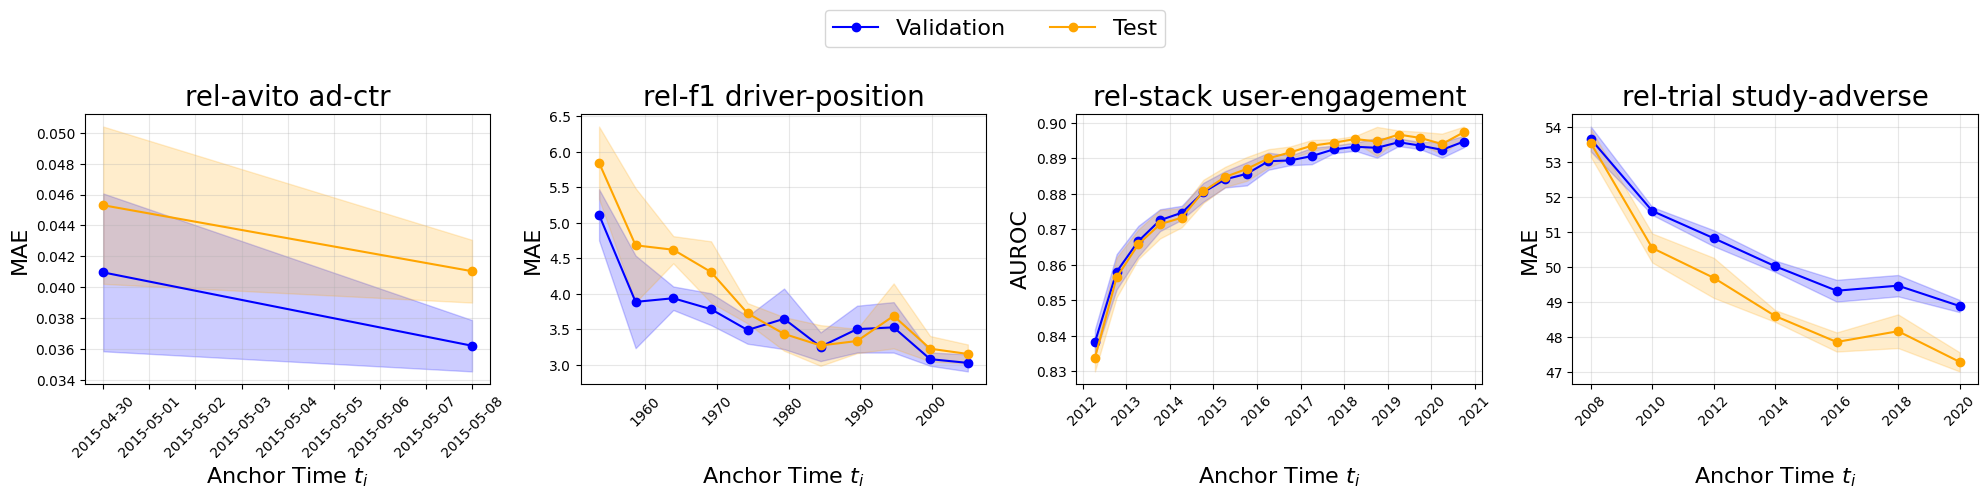

In [26]:


def make_val_test_metric_plots(
    dataset_pairs: list[tuple[str, str]], nrows: int = 4, ncols: int = 3, regime: str = "from_scratch", save_path: Optional[Path] = None
):
    fig, axes = plt.subplots(
        ncols=ncols, nrows=nrows, figsize=(5 * ncols, 4.5 * nrows), tight_layout=True
    )

    for i, (dataset_name, task_name) in tqdm(
        enumerate(dataset_pairs), total=len(dataset_pairs)
    ):
        ax = axes[i // ncols, i % ncols] if nrows > 1 else axes[i % ncols]

        wrapped_task = tasks[(dataset_name, task_name)]
        try:
            raw_predictions = pd.read_csv(
                f"./data/pelesjak_cl_{regime}/{dataset_name}_{task_name}_predictions.csv"
            )
        except FileNotFoundError:
            print(f"Predictions for {dataset_name} {task_name} not found, skipping.")
            continue
        raw_predictions[wrapped_task.full_table.time_col] = pd.to_datetime(
            raw_predictions[wrapped_task.full_table.time_col]
        )

        splits = wrapped_task.get_splits()
        
        metric = "auroc" if wrapped_task.task.task_type.value == "binary_classification" else "mae"
        val_metrics_list = []
        test_metrics_list = []
        val_metrics_std_list = []
        test_metrics_std_list = []
        splits_plot = []
        for j in range(1, len(splits) - 1):
            val_metrics = calculate_metric_for_split(
                raw_predictions,
                wrapped_task,
                j,
                wrapped_task.task.dataset.val_timestamp,
                wrapped_task.task.dataset.test_timestamp,
                decay=0,
                with_std=True
            )
            if val_metrics.get(metric, None) is None:
                continue
            test_metrics = calculate_metric_for_split(
                raw_predictions,
                wrapped_task,
                j,
                wrapped_task.task.dataset.test_timestamp,
                pd.Timestamp.max,
                decay=0,
                with_std=True
            )
            splits_plot.append(splits[j])
            val_metrics_list.append(val_metrics[metric])
            val_metrics_std_list.append(val_metrics[f"{metric}_std"])
            test_metrics_list.append(test_metrics[metric])
            test_metrics_std_list.append(test_metrics[f"{metric}_std"])
        ax.plot(
            splits_plot,
            val_metrics_list,
            marker="o",
            label="Validation",
            color="blue",
        )
        ax.fill_between(
            splits_plot,
            np.array(val_metrics_list) - np.array(val_metrics_std_list),
            np.array(val_metrics_list) + np.array(val_metrics_std_list),
            color="blue",
            alpha=0.2,
        )
        ax.plot(
            splits_plot,
            test_metrics_list,
            marker="o",
            label="Test",
            color="orange",
        )
        ax.fill_between(
            splits_plot,
            np.array(test_metrics_list) - np.array(test_metrics_std_list),
            np.array(test_metrics_list) + np.array(test_metrics_std_list),
            color="orange",
            alpha=0.2,
        )
        ax.set_xlabel("Anchor Time $t_i$", fontsize=16)
        ax.set_ylabel(metric.upper(), fontsize=16)
        ax.set_title(f"{dataset_name} {task_name}", fontsize=20)
        ax.grid(True, alpha=0.3, which="both")
        for tick in ax.get_xticklabels():
            tick.set_rotation(45)
            
            
    lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
    lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

    unique_labels = labels[:2]
    unique_lines = lines[:2]

    fig.legend(
        unique_lines,
        unique_labels,
        loc="lower center",
        ncol=2,
        prop={"size": 16},
        bbox_to_anchor=(0.5, 0.99),
    )
    fig.suptitle("")
    fig.align_xlabels()
    fig.align_ylabels()
    fig.tight_layout(h_pad=0)
    fig.show()
            
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        
# make_val_test_metric_plots(dataset_task_pairs, nrows=4, ncols=3, regime="from_scratch", save_path=Path("./data/figures/cl_from_scratch_val_test_full.png"))
make_val_test_metric_plots(cherry_picked_pairs, nrows=1, ncols=4, regime="from_scratch", save_path=Path("./data/figures/cl_from_scratch_val_test_cherry_picked.png"))


100%|██████████| 4/4 [00:00<00:00, 18.78it/s]
/tmp/ipykernel_120795/3854085792.py:166: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


best_val_roc_auc                         \
regime                             ft_full ft_upsample ft_newonly   
dataset   task                                                      
rel-stack user-engagement         0.879494    0.879904   0.880458   

                                       best_val_roc_auc_std              \
regime                    from_scratch              ft_full ft_upsample   
dataset   task                                                            
rel-stack user-engagement     0.879006             0.011539    0.011302   

                                                  first_val_roc_auc  \
regime                    ft_newonly from_scratch           ft_full   
dataset   task                                                        
rel-stack user-engagement   0.011291     0.009633          0.876142   

                                                               \
regime                    ft_upsample ft_newonly from_scratch   
dataset   task                                                  
rel-stack user-engagement    0.876578   0.878563     0.860368   

                          first_val_roc_auc_std                         \
regime                                  ft_full ft_upsample ft_newonly   
dataset   task                                                           
rel-stack user-engagement              0.012077    0.012635   0.012209   

                                        
regime                    from_scratch  
dataset   task                          
rel-stack user-engagement     0.006587

best_val_mae                                      \
regime                         ft_full ft_upsample ft_newonly from_scratch   
dataset   task                                                               
rel-avito ad-ctr              0.034231    0.034147   0.034413     0.034284   
rel-f1    driver-position     4.722930    4.674881   4.665503     4.608062   
rel-trial study-adverse      35.215502   35.343704  35.237921    35.974908   

                          best_val_mae_std                         \
regime                             ft_full ft_upsample ft_newonly   
dataset   task                                                      
rel-avito ad-ctr                  0.000551    0.000430   0.000318   
rel-f1    driver-position         0.912583    0.924194   0.885199   
rel-trial study-adverse           9.990927    9.885973  10.055521   

                                       first_val_mae                         \
regime                    from_scratch       ft_full ft_upsample ft_newonly   
dataset   task                                                                
rel-avito ad-ctr              0.000511      0.053755    0.054867   0.056329   
rel-f1    driver-position     0.952238      5.231729    5.292292   5.132677   
rel-trial study-adverse      10.669848     36.150591   36.458562  36.087797   

                                       first_val_mae_std              \
regime                    from_scratch           ft_full ft_upsample   
dataset   task                                                         
rel-avito ad-ctr              0.058883          0.016184    0.014504   
rel-f1    driver-position     8.329635          1.703825    1.700081   
rel-trial study-adverse      39.931657         10.005833    9.819130   

                                                   
regime                    ft_newonly from_scratch  
dataset   task                                     
rel-avito ad-ctr            0.013387     0.010705  
rel-f1    driver-position   1.708332     2.171735  
rel-trial study-adverse    10.061819    11.973944

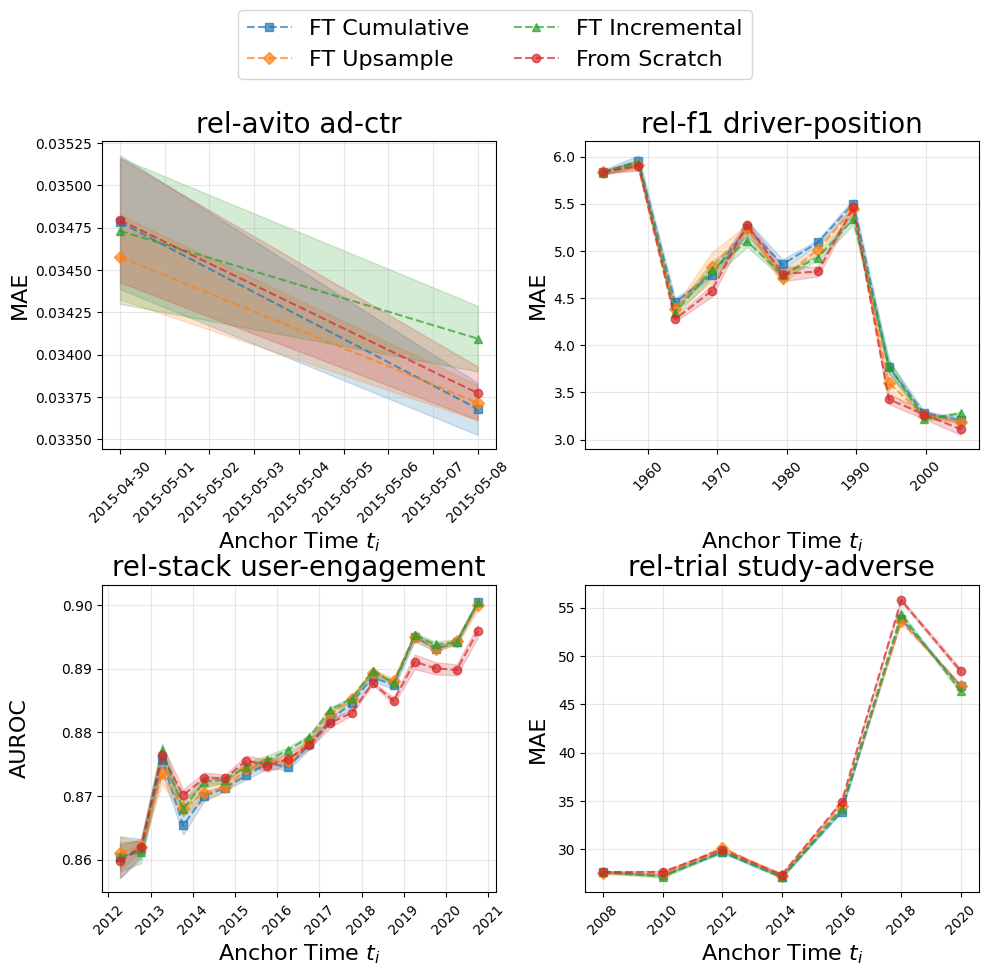

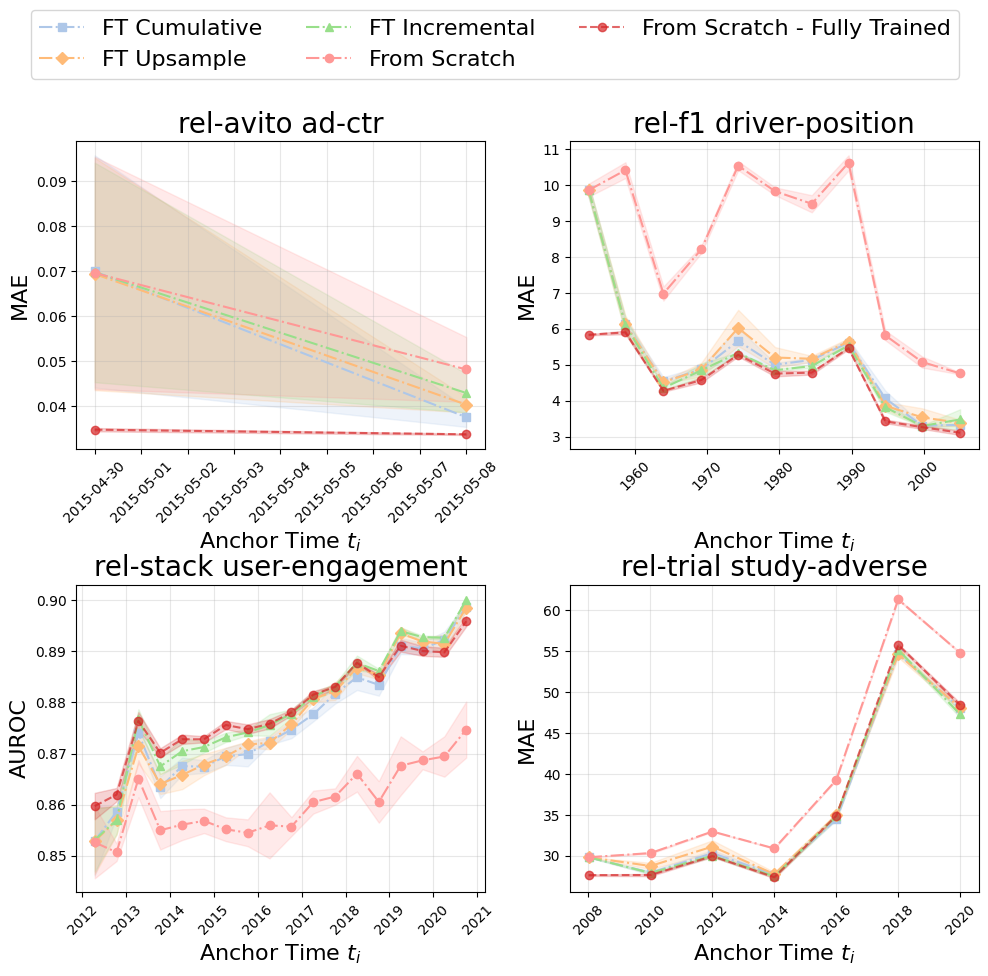

In [27]:
cmap = plt.get_cmap("tab20")


regimes = ["ft_full", "ft_upsample", "ft_newonly", "from_scratch"]

regime_to_label = {
    "from_scratch": "From Scratch",
    "ft_full": "FT Cumulative",
    "ft_upsample": "FT Upsample",
    "ft_newonly": "FT Incremental",
}

regime_to_marker = {
    "from_scratch": "o",
    "ft_full": "s",
    "ft_upsample": "D",
    "ft_newonly": "^",
}

metric_to_label = {"val_roc_auc": "AUROC", "val_mae": "MAE"}


def make_regime_comparison_plots(
    dataset_pairs: list[tuple[str, str]],
    nrows: int = 4,
    ncols: int = 3,
    save_path: Optional[Path] = None,
):
    fig1, axes1 = plt.subplots(
        ncols=ncols, nrows=nrows, figsize=(5 * ncols, 4.5 * nrows), tight_layout=True
    )
    fig2, axes2 = plt.subplots(
        ncols=ncols, nrows=nrows, figsize=(5 * ncols, 4.5 * nrows), tight_layout=True
    )

    metrics_dict_reg = defaultdict(list)
    metrics_dict_cls = defaultdict(list)

    for regime in regimes:
        df = pd.read_csv(f"./data/pelesjak_cl_{regime}.csv")
        for i, (dataset_name, task_name) in tqdm(
            enumerate(dataset_pairs), total=len(dataset_pairs)
        ):
            ax1 = axes1[i // ncols, i % ncols] if nrows > 1 else axes1[i % ncols]
            ax2 = axes2[i // ncols, i % ncols] if nrows > 1 else axes2[i % ncols]
            wrapped_task = tasks[(dataset_name, task_name)]

            splits = wrapped_task.get_splits()

            metric = (
                "val_roc_auc"
                if wrapped_task.task.task_type.value == "binary_classification"
                else "val_mae"
            )
            best_metrics = []
            best_metrics_std = []
            first_metrics = []
            first_metrics_std = []
            splits_plot = []

            df_subset = df[
                (df["dataset_name"] == dataset_name) & (df["task_name"] == task_name)
            ]
            for j in range(1, len(splits) - 1):
                split_df = df_subset[df_subset["increment"] == j]
                metrics_df = split_df[[f"best_{metric}", f"first_{metric}"]].mean()
                best_metrics.append(metrics_df[f"best_{metric}"])
                first_metrics.append(metrics_df[f"first_{metric}"])
                best_metrics_std.append(split_df[f"best_{metric}"].std())
                first_metrics_std.append(split_df[f"first_{metric}"].std())

            if wrapped_task.task.task_type.value == "binary_classification":
                metrics_dict_reg["regime"].append(regime)
                metrics_dict_reg["dataset"].append(dataset_name)
                metrics_dict_reg["task"].append(task_name)
                metrics_dict_reg[f"best_{metric}"].append(np.mean(best_metrics))
                metrics_dict_reg[f"best_{metric}_std"].append(np.std(best_metrics))
                metrics_dict_reg[f"first_{metric}"].append(np.mean(first_metrics))
                metrics_dict_reg[f"first_{metric}_std"].append(np.std(first_metrics))
            else:
                metrics_dict_cls["regime"].append(regime)
                metrics_dict_cls["dataset"].append(dataset_name)
                metrics_dict_cls["task"].append(task_name)
                metrics_dict_cls[f"best_{metric}"].append(np.mean(best_metrics))
                metrics_dict_cls[f"best_{metric}_std"].append(np.std(best_metrics))
                metrics_dict_cls[f"first_{metric}"].append(np.mean(first_metrics))
                metrics_dict_cls[f"first_{metric}_std"].append(np.std(first_metrics))

            ax1.plot(
                splits[1:-1],
                best_metrics,
                marker=regime_to_marker.get(regime, "o"),
                label=f"{regime_to_label.get(regime, regime)}",
                color=cmap((regimes.index(regime) * 2)),
                linestyle="--",
                alpha=0.7,
            )
            ax1.fill_between(
                splits[1:-1],
                np.array(best_metrics) - np.array(best_metrics_std),
                np.array(best_metrics) + np.array(best_metrics_std),
                color=cmap((regimes.index(regime) * 2)),
                alpha=0.2,
            )

            ax2.plot(
                splits[1:-1],
                first_metrics,
                marker=regime_to_marker.get(regime, "o"),
                label=f"{regime_to_label.get(regime, regime)}",
                color=cmap((regimes.index(regime) * 2 + 1)),
                linestyle="-.",
            )
            ax2.fill_between(
                splits[1:-1],
                np.array(first_metrics) - np.array(first_metrics_std),
                np.array(first_metrics) + np.array(first_metrics_std),
                color=cmap((regimes.index(regime) * 2 + 1)),
                alpha=0.2,
            )
            if regime == "from_scratch":
                ax2.plot(
                    splits[1:-1],
                    best_metrics,
                    marker=regime_to_marker.get(regime, "o"),
                    label=f"{regime_to_label.get(regime, regime)} - Fully Trained",
                    color=cmap((regimes.index(regime) * 2)),
                    linestyle="--",
                    alpha=0.7,
                )
                ax2.fill_between(
                    splits[1:-1],
                    np.array(best_metrics) - np.array(best_metrics_std),
                    np.array(best_metrics) + np.array(best_metrics_std),
                    color=cmap((regimes.index(regime) * 2)),
                    alpha=0.2,
                )
            for ax in [ax1, ax2]:
                ax.set_xlabel("Anchor Time $t_i$", fontsize=16)
                ax.set_ylabel(metric_to_label.get(metric, metric), fontsize=16)
                ax.set_title(f"{dataset_name} {task_name}", fontsize=20)
                ax.grid(True, alpha=0.3, which="both")
                for tick in ax.get_xticklabels():
                    tick.set_rotation(45)

    for fig in [fig1, fig2]:
        num_labels = len(regimes) + 1 if fig == fig2 else len(regimes)
        lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
        lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

        unique_labels = labels[:num_labels]
        unique_lines = lines[:num_labels]

        fig.legend(
            unique_lines,
            unique_labels,
            loc="lower center",
            ncol=2 if num_labels < 5 else 3,
            prop={"size": 16},
            bbox_to_anchor=(0.5, 0.99),
        )
        fig.suptitle("")
        fig.align_xlabels()
        fig.align_ylabels()
        fig.tight_layout(h_pad=0)
        fig.show()
    # for ax in axes.flatten():
    #     ax.imshow(cmap='tab20')

    metrics_df_reg = pd.DataFrame(metrics_dict_reg)
    metrics_df_cls = pd.DataFrame(metrics_dict_cls)

    metrics_df_reg.set_index(["dataset", "task", "regime"], inplace=True)
    metrics_df_cls.set_index(["dataset", "task", "regime"], inplace=True)
    metrics_df_reg = metrics_df_reg.unstack("regime")
    metrics_df_cls = metrics_df_cls.unstack("regime")
    metrics_df_reg = metrics_df_reg.reindex(regimes, axis=1, level=1)
    metrics_df_cls = metrics_df_cls.reindex(regimes, axis=1, level=1)

    display(metrics_df_reg)
    display(metrics_df_cls)
    
    if save_path:
        fig1.savefig(save_path.parent / f"{save_path.stem}_best.png", dpi=300, bbox_inches='tight')
        fig2.savefig(save_path.parent / f"{save_path.stem}_first.png", dpi=300, bbox_inches='tight')
        


# make_regime_comparison_plots(
#     dataset_task_pairs,
#     nrows=4,
#     ncols=3,
#     save_path=Path("./data/figures/cl_regime_comparison_full"),
# )
make_regime_comparison_plots(
    cherry_picked_pairs,
    nrows=2,
    ncols=2,
    save_path=Path("./data/figures/cl_regime_comparison_cherry_picked_2x2"),
)

In [36]:
regimes = ["ft_full", "ft_upsample", "ft_newonly", "from_scratch"]

regime_to_label = {
    "from_scratch": "Scratch",
    "ft_full": "FT Cuml.",
    "ft_upsample": "FT Upspl.",
    "ft_newonly": "FT Incr.",
}

metric_to_label = {"val_roc_auc": "AUROC", "val_mae": "MAE"}

def make_decay_metric_plots(
    dataset_pairs: list[tuple[str, str]], save_path: Optional[Path] = None
):
    data_reg_dict =  defaultdict(list)
    data_cls_dict =  defaultdict(list)
    for regime in regimes:
        for i, (dataset_name, task_name) in tqdm(
            enumerate(dataset_pairs), total=len(dataset_pairs)
        ):

            wrapped_task = tasks[(dataset_name, task_name)]
            try:
                raw_predictions = pd.read_csv(
                    f"./data/pelesjak_cl_{regime}/{dataset_name}_{task_name}_predictions.csv"
                )
            except FileNotFoundError:
                print(f"Predictions for {dataset_name} {task_name} not found, skipping.")
                continue
            raw_predictions[wrapped_task.full_table.time_col] = pd.to_datetime(
                raw_predictions[wrapped_task.full_table.time_col]
            )

            splits = wrapped_task.get_splits()
            
            metric = "auroc" if wrapped_task.task.task_type.value == "binary_classification" else "mae"
            
            num_splits = len(splits)
            model_increment = num_splits - 2
            
            data_dict = data_reg_dict if wrapped_task.task.task_type.value == "regression" else data_cls_dict
            
            for k, decay in enumerate([0.0, 0.3, 0.9]):
                test_metrics = calculate_metric_for_split(
                    raw_predictions,
                    wrapped_task,
                    model_increment,
                    splits[-2],
                    pd.Timestamp.max,
                    decay=decay,
                    with_std=True
                )
                data_dict["dataset"].append(dataset_name)
                data_dict["task"].append(task_name)
                data_dict["regime"].append(regime_to_label[regime])
                data_dict["decay"].append(str(decay))
                data_dict[metric].append(test_metrics[metric])
                data_dict[f"{metric}_std"].append(test_metrics[f"{metric}_std"])
            
    data_reg_df = pd.DataFrame(data_reg_dict)
    data_cls_df = pd.DataFrame(data_cls_dict)
    data_reg_df.set_index(["dataset", "task", "regime", "decay"], inplace=True)
    data_cls_df.set_index(["dataset", "task", "regime", "decay"], inplace=True)
    data_reg_df = data_reg_df.unstack("regime")
    data_cls_df = data_cls_df.unstack("regime")
    data_reg_df.columns = data_reg_df.columns.swaplevel(0, 1)
    data_cls_df.columns = data_cls_df.columns.swaplevel(0, 1)
    data_reg_df.sort_index(axis=1, level=0, inplace=True)
    display(data_reg_df)
    display(data_cls_df)
            
    if save_path:
        data_reg_df.to_latex(save_path.parent / f"{save_path.stem}_reg.tex", float_format="{:.3f}".format, escape=True)
        data_cls_df.to_latex(save_path.parent / f"{save_path.stem}_cls.tex", float_format="{:.3f}".format, escape=True)
        
make_decay_metric_plots(dataset_task_pairs, save_path=Path("./data/tables/decay_metric_full"))
# make_decay_metric_plots(cherry_picked_pairs, save_path=Path("./data/figures/decay_metric_cherry_picked.png"))


100%|██████████| 12/12 [01:03<00:00,  5.25s/it]


regime                            FT Cuml.             FT Incr.            \
                                       mae   mae_std        mae   mae_std   
dataset   task            decay                                             
rel-avito ad-ctr          0.0     0.037231  0.000620   0.037419  0.000572   
                          0.3     0.036820  0.000635   0.037037  0.000550   
                          0.9     0.035310  0.000698   0.035632  0.000543   
rel-f1    driver-position 0.0     3.256251  0.056136   3.408470  0.052895   
                          0.3     2.858485  0.054747   2.922147  0.021429   
                          0.9     3.466110  0.135497   3.293104  0.106835   
rel-stack post-votes      0.0     0.061493  0.000495   0.062407  0.001102   
                          0.3     0.061003  0.000520   0.061945  0.001107   
                          0.9     0.059197  0.000613   0.060243  0.001148   
rel-trial site-success    0.0     0.428255  0.017095   0.394848  0.003309   
                          0.3     0.430587  0.016105   0.395716  0.003298   
                          0.9     0.439566  0.014304   0.399059  0.005465   
          study-adverse   0.0    46.368747  0.104138  45.995852  0.320847   
                          0.3    46.565314  0.092497  46.162847  0.299955   
                          0.9    47.239091  0.119988  46.735258  0.266963   

regime                           FT Upspl.              Scratch            
                                       mae   mae_std        mae   mae_std  
dataset   task            decay                                            
rel-avito ad-ctr          0.0     0.039378  0.001897   0.038652  0.001836  
                          0.3     0.038951  0.001903   0.038225  0.001804  
                          0.9     0.037379  0.001928   0.036653  0.001693  
rel-f1    driver-position 0.0     3.278315  0.104302   3.106221  0.124926  
                          0.3     3.058454  0.152635   2.826756  0.116319  
                          0.9     3.569117  0.316107   3.358359  0.247477  
rel-stack post-votes      0.0     0.062219  0.000839   0.065690  0.001570  
                          0.3     0.061783  0.000876   0.065163  0.001587  
                          0.9     0.060178  0.001012   0.063223  0.001654  
rel-trial site-success    0.0     0.419456  0.007620   0.392785  0.012627  
                          0.3     0.419799  0.006088   0.391906  0.010616  
                          0.9     0.421118  0.006296   0.388521  0.006986  
          study-adverse   0.0    46.544921  0.304195  48.143170  0.182802  
                          0.3    46.819443  0.298674  48.281372  0.174793  
                          0.9    47.760428  0.326728  48.755089  0.169666

regime                           FT Cuml.  FT Incr. FT Upspl.   Scratch  \
                                    auroc     auroc     auroc     auroc   
dataset   task            decay                                           
rel-avito user-clicks     0.0    0.658671  0.659199  0.656104  0.647804   
                          0.3    0.656563  0.657046  0.653695  0.646105   
                          0.9    0.645342  0.645580  0.640867  0.637058   
          user-visits     0.0    0.664611  0.666446  0.666437  0.665887   
                          0.3    0.666819  0.668811  0.668842  0.668118   
                          0.9    0.675513  0.678121  0.678307  0.676899   
rel-f1    driver-dnf      0.0    0.763023  0.818313  0.775644  0.813909   
                          0.3    0.737333  0.759016  0.744777  0.755398   
                          0.9    0.694725  0.716120  0.686535  0.669892   
          driver-top3     0.0    0.892076  0.897910  0.840676  0.867357   
                          0.3    0.779487  0.778829  0.725140  0.753553   
                          0.9    0.689148  0.670744  0.658918  0.653480   
rel-stack user-badge      0.0    0.889473  0.889770  0.889194  0.881611   
                          0.3    0.890488  0.890674  0.890068  0.882849   
                          0.9    0.894227  0.894002  0.893290  0.887410   
          user-engagement 0.0    0.902124  0.900898  0.901112  0.896012   
                          0.3    0.901780  0.900605  0.900763  0.895780   
                          0.9    0.900515  0.899527  0.899482  0.894925   
rel-trial study-outcome   0.0    0.632886  0.652970  0.637842  0.656903   
                          0.3    0.631386  0.651418  0.635171  0.655551   
                          0.9    0.626251  0.646103  0.626023  0.650922   

regime                           FT Cuml.  FT Incr. FT Upspl.   Scratch  
                                auroc_std auroc_std auroc_std auroc_std  
dataset   task            decay                                          
rel-avito user-clicks     0.0    0.005084  0.006172  0.011282  0.013072  
                          0.3    0.004438  0.005639  0.010481  0.011836  
                          0.9    0.002073  0.003795  0.007114  0.005979  
          user-visits     0.0    0.003008  0.001599  0.000510  0.003489  
                          0.3    0.003056  0.001549  0.000601  0.003605  
                          0.9    0.003288  0.001550  0.000980  0.004096  
rel-f1    driver-dnf      0.0    0.016110  0.001317  0.008455  0.010563  
                          0.3    0.034003  0.015312  0.023854  0.015613  
                          0.9    0.073695  0.004457  0.052793  0.024594  
          driver-top3     0.0    0.006364  0.002842  0.009330  0.016027  
                          0.3    0.006604  0.009039  0.029186  0.019918  
                          0.9    0.017720  0.015620  0.053031  0.047794  
rel-stack user-badge      0.0    0.000273  0.000813  0.000883  0.000490  
                          0.3    0.000293  0.000848  0.000959  0.000510  
                          0.9    0.000416  0.000998  0.001242  0.000755  
          user-engagement 0.0    0.000820  0.000624  0.000687  0.001379  
                          0.3    0.000859  0.000617  0.000709  0.001386  
                          0.9    0.001014  0.000623  0.000794  0.001535  
rel-trial study-outcome   0.0    0.006385  0.005464  0.023557  0.004386  
                          0.3    0.005934  0.005067  0.023529  0.004294  
                          0.9    0.006594  0.004054  0.023636  0.004834